Here, we see how our loss changes as a function of the various hyperparameters we were interested in:

In [1]:
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams

In [2]:
seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'


In [21]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

In [22]:
best_emd_mean

,,,emd_loss_total
max_epochs,max_lr,train_batch_size,
600.0,0.001,1024.0,247.708224


In [23]:
best_emd

,max_epochs,max_lr,train_batch_size,k,emd_loss_total,KL_regularization
10,600.0,0.001,1024.0,0.0,255.468449,0.01
11,600.0,0.001,1024.0,1.0,229.876968,0.01
12,600.0,0.001,1024.0,2.0,219.365871,0.01
13,600.0,0.001,1024.0,3.0,264.572777,0.01
14,600.0,0.001,1024.0,4.0,269.257057,0.01


The following has an outlier loss value, so for visualization, we disregard it:

In [16]:
outlier = res[(res.max_epochs == 1200) & (res.train_batch_size == 1024) & (res.max_lr == 0.001)]
outlier

,max_epochs,max_lr,train_batch_size,k,emd_loss_total,KL_regularization
70,1200.0,0.001,1024.0,0.0,266.849388,0.01
71,1200.0,0.001,1024.0,1.0,248.897552,0.01
72,1200.0,0.001,1024.0,2.0,245.462101,0.01
73,1200.0,0.001,1024.0,3.0,275.590900,0.01
74,1200.0,0.001,1024.0,4.0,209386.008789,0.01


In [17]:
res.drop(index = outlier.index, inplace = True)

''

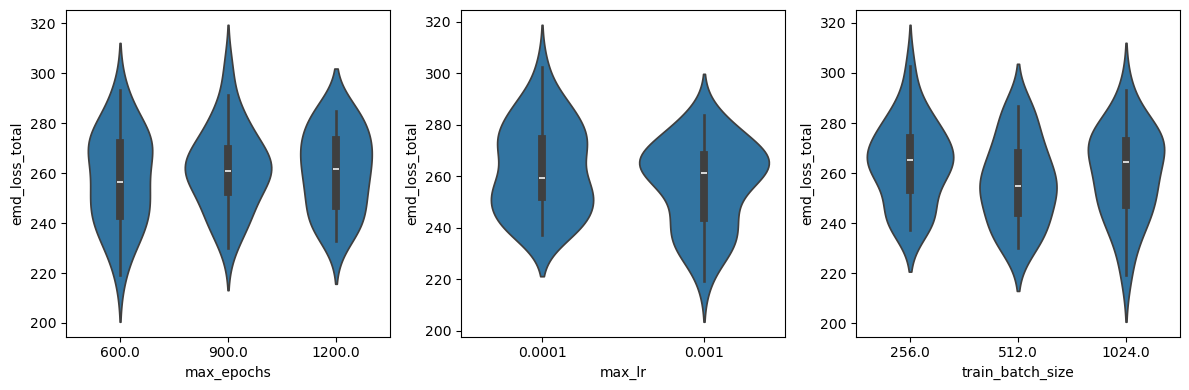

In [18]:
fig, ax = plt.subplots(figsize = (12, 4), ncols = 3)

sns.violinplot(data = res, x = 'max_epochs', y = 'emd_loss_total', ax = ax[0])
sns.violinplot(data = res, x = 'max_lr', y = 'emd_loss_total', ax = ax[1])
sns.violinplot(data = res, x = 'train_batch_size', y = 'emd_loss_total', ax = ax[2])
fig.tight_layout()
;

<Axes: xlabel='max_epochs', ylabel='max_lr'>

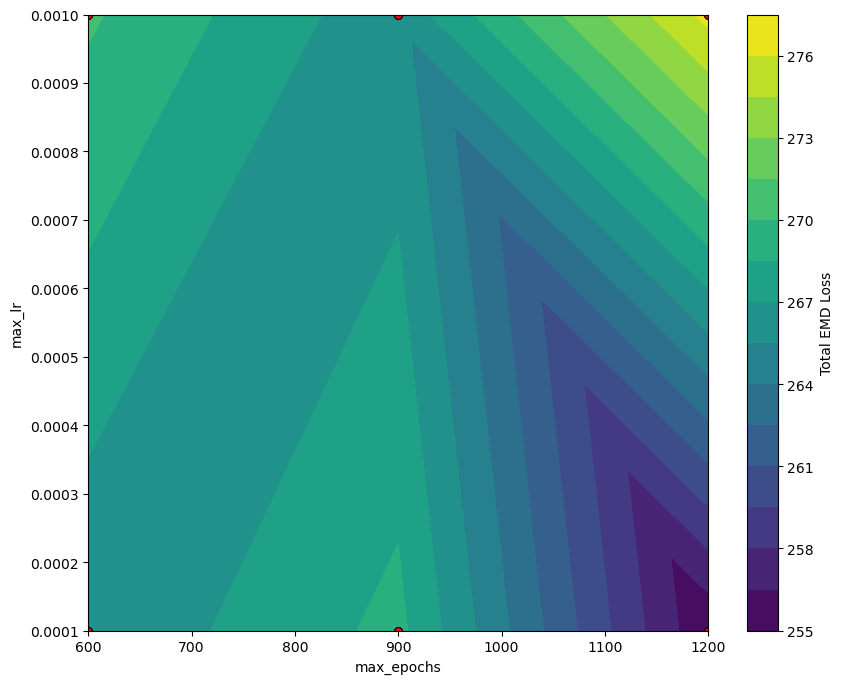

In [19]:
plt.figure(figsize=(10, 8))
viz_df = res[res.emd_loss_total.notna()]
x = viz_df.max_epochs
y = viz_df.max_lr
z = viz_df.emd_loss_total

contour = plt.tricontourf(x, y, z, levels=20, cmap="viridis")
plt.colorbar(contour, label="Total EMD Loss")

# Add scatter plot of the points for reference
sns.scatterplot(x=x, y=y, color='red', s=30, edgecolor='black')
